In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
# matplotlib.use("Agg") #figures are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [6]:
#DATA DESCRIPTIONS

### Data Type
# ARMBE: ARM Best Estimate Data Products

### Link
# https://armgov.svcs.arm.gov/data/science-data-products/vaps/armbe

### Summary
# This data product, formerly known as the Climate Modeling Best Estimate (CMBE) data set, 
# assembles a best estimate of cloud, radiation, and atmospheric quantities, 
# and surface/land properties that are both well observed by ARM
# and commonly used in model evaluation into one single data set. 
# For over two decades, most of these quantities have been measured by ARM ground-based instruments, 
# including cloud radars, micropulse lidars (MPLs), laser ceilometers, microwave radiometers (MWRs), 
# and solar and infrared radiation stations (SIRSs).

### Temporal Coverage
# Begin datetime	2022-05-25 00:00:00
# End datetime	2021-10-01 00:30:00

### Spatial Coverage
# Located at TRACER ARM M1 Facility at (29.67N, 95.059W)

In [7]:
################################################################################

In [149]:
#SET UP DIRECTORIES
Campaign="TRACER"
DataType="Kollias_Algorithm_Output"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign=Campaign,
                     DataType=DataType,
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"):
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    Data_Directory = os.path.join(BaseDir, Campaign, DataType)
    # Data_Directory = os.path.join(BaseDir, Campaign, DataType, 'bnd')
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = ListFiles(Data_Directory)
    FileList = [f for f in FileList if f != "bnd"] #remove directory
    return Data_Directory, FileList

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER 



In [150]:
#READING DATA FUNCTIONS
###################################

In [151]:
import xarray as xr
def GetData(Data_Directory, FileList, index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    # print(f"Downloading File:\n {DataFile}","\n")
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC, DataFile

In [152]:
#READING DATA
###################################

In [153]:
#GETTING DATA
[Data_Directory, FileList] = GetDataDirectory()
[DataNC, DataFile] = GetData(Data_Directory, FileList, index=1) #index 0 = 0630, index 1 = 0701
print("Setting DataFile as: ",DataFile)

Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/Kollias_Algorithm_Output 

Setting DataFile as:  /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/Kollias_Algorithm_Output/houarsclkazr1kolliasM1.c1.20220701.000000.nc


In [154]:
DataNC.data_vars

Data variables:
    base_time                             datetime64[ns] 8B ...
    time_offset                           (time) datetime64[ns] 173kB ...
    reflectivity_best_estimate            (time, height) float32 51MB ...
    qc_reflectivity_best_estimate         (time, height) int32 51MB ...
    reflectivity                          (time, height) float32 51MB ...
    qc_reflectivity                       (time, height) int32 51MB ...
    mean_doppler_velocity                 (time, height) float32 51MB ...
    qc_mean_doppler_velocity              (time, height) int32 51MB ...
    spectral_width                        (time, height) float32 51MB ...
    qc_spectral_width                     (time, height) int32 51MB ...
    linear_depolarization_ratio           (time, height) float32 51MB ...
    qc_linear_depolarization_ratio        (time, height) int32 51MB ...
    signal_to_noise_ratio                 (time, height) float32 51MB ...
    reflectivity_clutter_flag             

In [141]:
#PLOTTING DATA FUNCTION
###################################

In [142]:
def PlotVariable(variable):
    DataNC[variable].T.plot()

In [130]:
#PLOTTING DATA
###################################

(0.0, 18.025001525878906)

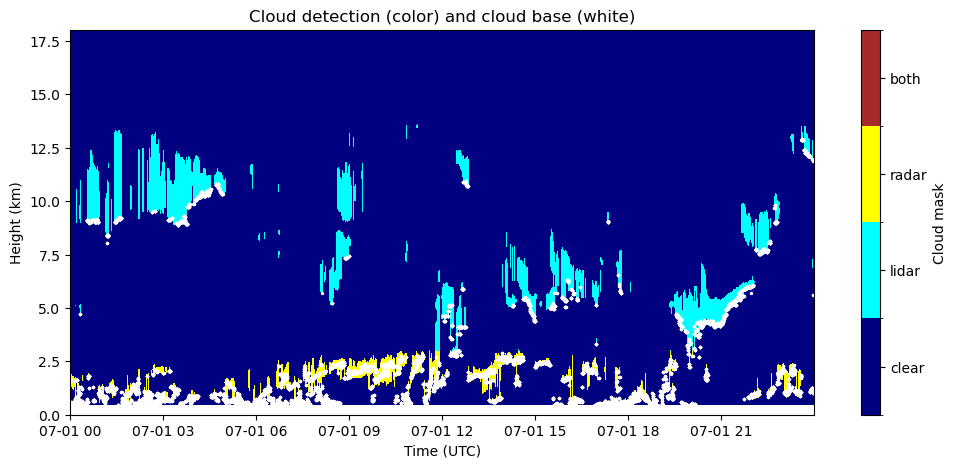

In [131]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

cloud_mask = DataNC['cloud_mask_mplzwang']  # time x height
cloud_base = DataNC['cloud_base_best_estimate']  # time

# colormap setup
cmap = ListedColormap(["navy", "cyan", "yellow", "brown"])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(12,5))
time = DataNC['time'].values
height = DataNC['height'].values / 1000.0  # if in meters, convert to km

# plot
mesh = plt.pcolormesh(time, height, cloud_mask.T, cmap=cmap, norm=norm, shading='auto')
cbar = plt.colorbar(mesh, label="Cloud mask")
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(["clear", "lidar", "radar", "both"])

# overlay cloud base
plt.scatter(time, cloud_base/1000.0, s=2, c='white')  # also convert to km

plt.ylabel("Height (km)")
plt.xlabel("Time (UTC)")
plt.title("Cloud detection (color) and cloud base (white)")


plt.ylim(bottom=0)


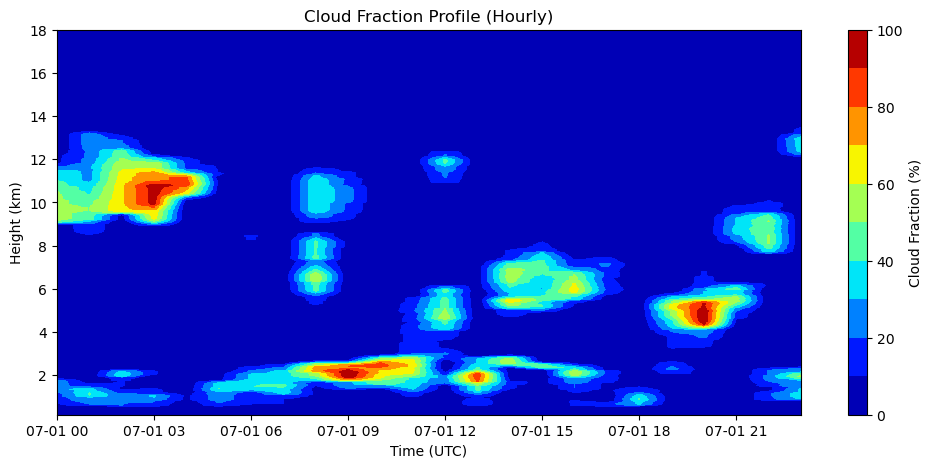

In [133]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# open file
ds = DataNC

# binary mask: 1 if cloudy, 0 if clear
cloud_mask = (ds['cloud_mask_mplzwang'] > 0).astype(int)

# resample in time (hourly mean)
cf_hourly = cloud_mask.resample(time="1h").mean(dim="time") * 100  # %

# extract coordinates
time = cf_hourly['time'].values
height = ds['height'].values / 1000.0  # km

# plot
plt.figure(figsize=(12,5))
cf_plot = plt.contourf(time, height, cf_hourly.T, levels=np.arange(0, 101, 10), cmap="jet")
cbar = plt.colorbar(cf_plot, label="Cloud Fraction (%)")

plt.ylabel("Height (km)")
plt.xlabel("Time (UTC)")
plt.title("Cloud Fraction Profile (Hourly)")
plt.show()


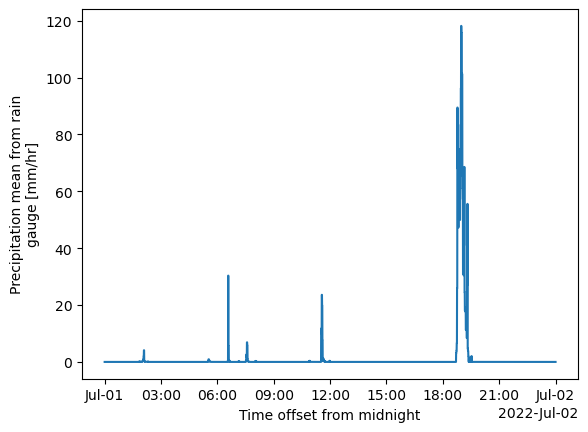

In [134]:
PlotVariable('precip_mean')

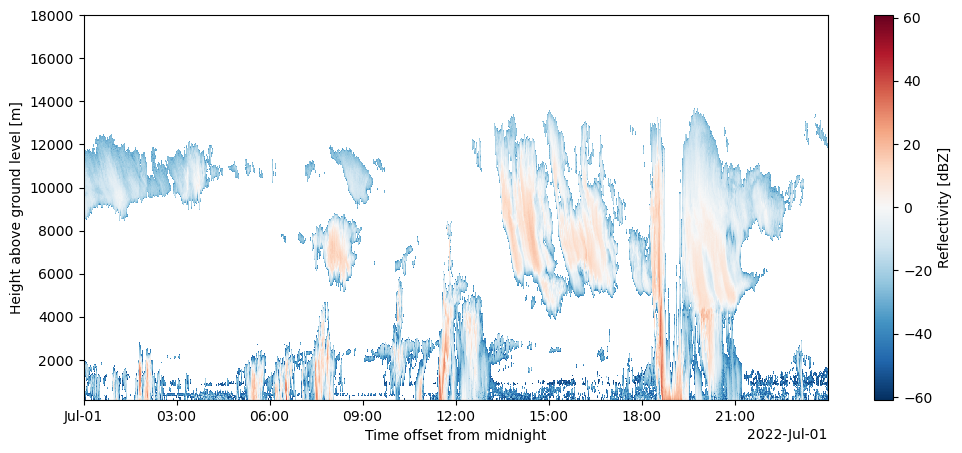

In [135]:
plt.figure(figsize=(12,5))
PlotVariable('reflectivity')

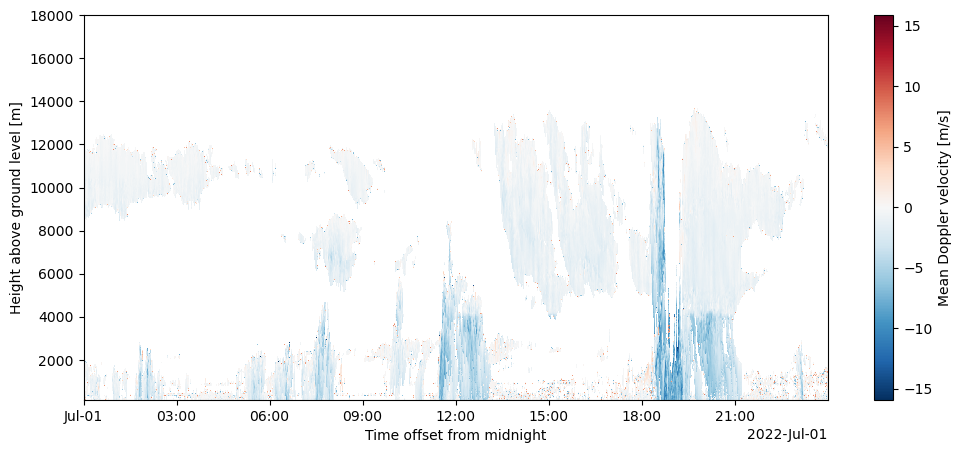

In [136]:
plt.figure(figsize=(12,5))
PlotVariable('mean_doppler_velocity')

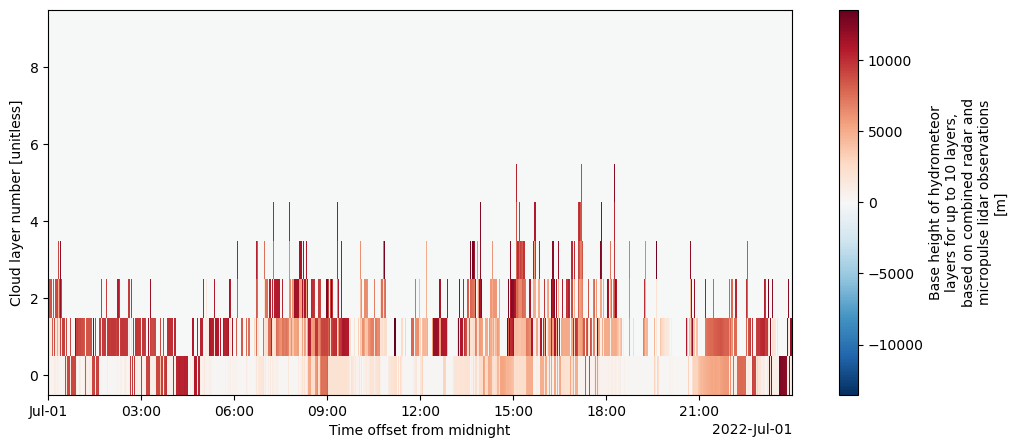

In [137]:
plt.figure(figsize=(12,5))
PlotVariable('cloud_layer_base_height')

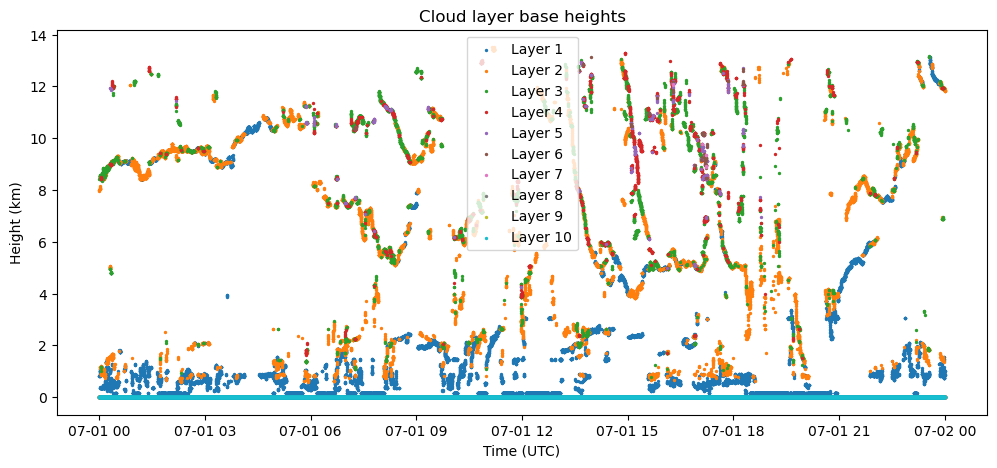

In [158]:
plt.figure(figsize=(12,5))

time = DataNC['time'].values
cloud_bases = DataNC['cloud_layer_base_height'].values / 1000.0  # km

for layer in range(cloud_bases.shape[1]):
    plt.scatter(time, cloud_bases[:, layer], s=2, label=f'Layer {layer+1}')

plt.ylabel("Height (km)")
plt.xlabel("Time (UTC)")
plt.title("Cloud layer base heights")
plt.legend()
plt.show()

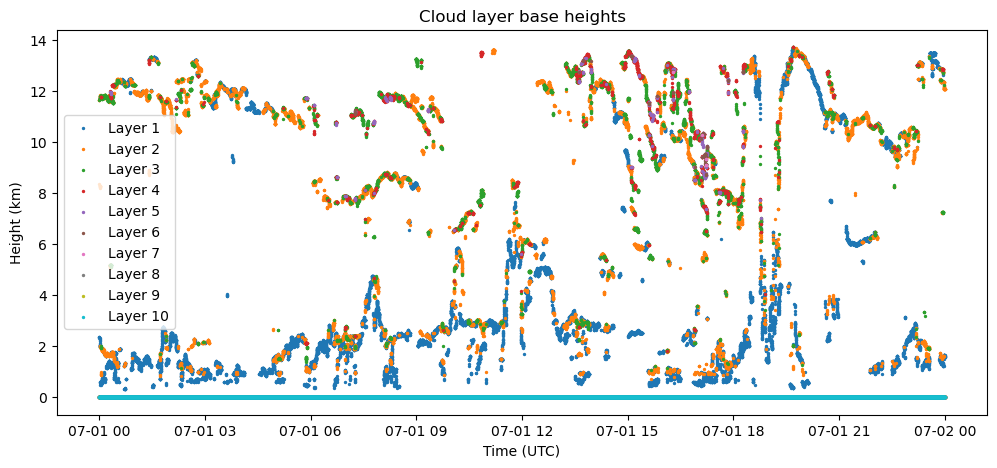

In [155]:
plt.figure(figsize=(12,5))

time = DataNC['time'].values
cloud_bases = DataNC['cloud_layer_top_height'].values / 1000.0  # km

for layer in range(cloud_bases.shape[1]):
    plt.scatter(time, cloud_bases[:, layer], s=2, label=f'Layer {layer+1}')

plt.ylabel("Height (km)")
plt.xlabel("Time (UTC)")
plt.title("Cloud layer base heights")
plt.legend()
plt.show()
